## EEG BrainLat — Pré-processamento e Extração de Features
### 2_Preprocessing

---

**Objetivo:** explorar os dados, pré-processar os sinais EEG e gerar o CSV com features espectrais **e de conectividade funcional** para uso nos modelos de ML.

---

#### Estrutura do Notebook

| Fase | Descrição |
|------|-----------|
| **0 — Configuração** | Imports globais e definição de caminhos |
| **2 — Exploração** | Metadados demográficos e técnicos |
| **3 — Pré-processamento** | Filtragem, epocagem, extração espectral **+ conectividade funcional** |

---


---
### Fase 0 — Configuração Global

Todos os imports e constantes estão centralizados aqui.
**Execute esta fase antes de qualquer outra.**


In [1]:
# 0.1 -- Imports Globais
import os
import re
import warnings
import traceback
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mne
from mne.time_frequency import psd_array_welch

from scipy.signal import hilbert, butter, sosfiltfilt

warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

SEED = 42
np.random.seed(SEED)
print("Imports carregados com sucesso.")


Imports carregados com sucesso.


In [2]:
# 0.2 -- Configuração de Caminhos e Constantes 

ROOT_DIR = "./Dataset_EEG_Alzheimer"

DIR_AD = os.path.join(ROOT_DIR, "dataset_eeg_alzheimer")
DIR_HC = os.path.join(ROOT_DIR, "dataset_eeg_hc")

# Validação de caminhos
assert os.path.exists(DIR_AD), f"Diretório AD não encontrado: {DIR_AD}"
assert os.path.exists(DIR_HC), f"Diretório HC não encontrado: {DIR_HC}"

# IDs Synapse (documentação)
SYNAPSE_ID_AD = "syn53222482"
SYNAPSE_ID_HC = "syn53222486"

# Saídas
OUT_CSV_FULL = "eeg_features_brainlat_FULL.csv"
OUT_CSV_FAILED = "eeg_features_brainlat_failures.csv"

# 🔴 MAPEAMENTO CENTRAL DE CLASSES (usado em TODO o pipeline)
LABEL_MAP = {"HC": 0, "AD": 1}

# 🔒 Validação do mapeamento
assert set(LABEL_MAP.keys()) == {"HC", "AD"}
assert set(LABEL_MAP.values()) == {0, 1}

# Bandas espectrais
BANDS = {
    "Delta": (0.5,  4.0),
    "Theta": (4.0,  8.0),
    "Alpha": (8.0, 13.0),
    "Beta" : (13.0, 30.0),
    "Gamma": (30.0, 45.0),
}
FMIN, FMAX = 0.5, 45.0

# Bandas para conectividade
CONN_BANDS = {
    "Theta": (4.0,  8.0),
    "Alpha": (8.0, 13.0),
    "Beta" : (13.0, 30.0),
}

# Features usadas no ML
FEATURE_COLS = [
    "Rel_Theta_mean",
    "Rel_Alpha_mean",
    "Rel_Beta_mean",
    "Rel_Gamma_mean",
    "Razao_Theta_Alpha",
    "Razao_Theta_Beta",
    "Spectral_Entropy",
    "PLV_Theta_mean",
    "PLV_Alpha_mean",
    "PLV_Beta_mean",
    "Corr_Broadband_mean",
]

# 🔒 Validações críticas
assert all(isinstance(f, str) for f in FEATURE_COLS), "FEATURE_COLS inválido"
assert len(FEATURE_COLS) == len(set(FEATURE_COLS)), "Features duplicadas detectadas"

print("Configuração carregada com sucesso.\n")
print(f"Diretório AD : {DIR_AD}")
print(f"Diretório HC : {DIR_HC}")
print(f"Nº de features: {len(FEATURE_COLS)}")
print(f"Classes: {LABEL_MAP}")

Configuração carregada com sucesso.

Diretório AD : ./Dataset_EEG_Alzheimer\dataset_eeg_alzheimer
Diretório HC : ./Dataset_EEG_Alzheimer\dataset_eeg_hc
Nº de features: 11
Classes: {'HC': 0, 'AD': 1}


---
### Fase 2 — Exploração do Dataset

Antes de processar os sinais, caracterizamos:
- Número de participantes por grupo.
- Distribuição demográfica (idade, sexo, país).
- Propriedades técnicas do sinal (duração, taxa de amostragem, número de canais).
- Inspeção visual de um traçado EEG bruto.


Carregados: 35 AD | 46 HC
Colunas disponíveis: ['path', 'id EEG', 'diagnosis', 'sex', 'Age', 'years_education', 'laterality', 'group']


,path,id EEG,diagnosis,sex,Age,years_education,laterality,group
0,1-AD/AR,sub-30001,AD,1,81,12,1.0,AD
1,1-AD/AR,sub-30002,AD,1,79,9,1.0,AD
2,1-AD/AR,sub-30004,AD,1,70,9,1.0,AD
3,1-AD/AR,sub-30008,AD,1,80,2,1.0,AD


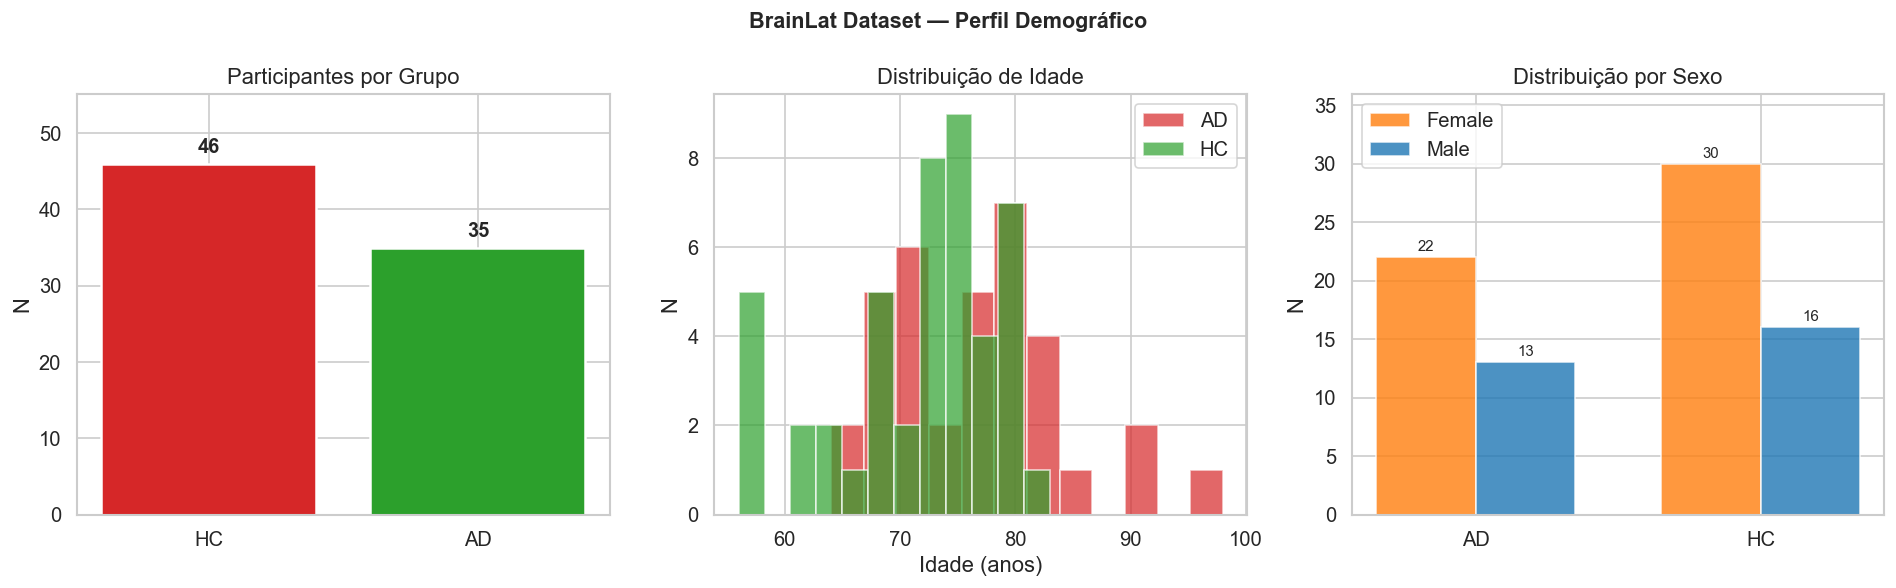

In [3]:
# 2.1 -- Análise Demográfica
path_demo_ad = os.path.join(DIR_AD, "demographics_ad_eeg_data.csv")
path_demo_hc = os.path.join(DIR_HC, "demographics_hc_eeg_data.csv")

try:
    df_ad_demo = pd.read_csv(path_demo_ad)
    df_hc_demo = pd.read_csv(path_demo_hc)
    df_ad_demo["group"] = "AD"
    df_hc_demo["group"] = "HC"
    df_demo = pd.concat([df_ad_demo, df_hc_demo], ignore_index=True)
    print(f"Carregados: {len(df_ad_demo)} AD | {len(df_hc_demo)} HC")
    print(f"Colunas disponíveis: {list(df_demo.columns)}")
    display(df_demo.head(4))

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("BrainLat Dataset — Perfil Demográfico", fontsize=13, fontweight="bold")

    counts_grp = df_demo["group"].value_counts()
    bars = axes[0].bar(counts_grp.index, counts_grp.values,
                       color=["#d62728", "#2ca02c"], edgecolor="white", lw=1.5)
    axes[0].bar_label(bars, fontsize=12, fontweight="bold", padding=4)
    axes[0].set_title("Participantes por Grupo")
    axes[0].set_ylabel("N")
    axes[0].set_ylim(0, counts_grp.max() * 1.2)

    col_age = next((c for c in df_demo.columns if "age" in c.lower()), None)
    if col_age:
        for grp, col in [("AD", "#d62728"), ("HC", "#2ca02c")]:
            axes[1].hist(df_demo.loc[df_demo["group"] == grp, col_age].dropna(),
                         bins=12, alpha=0.7, color=col, label=grp)
        axes[1].set_title("Distribuição de Idade")
        axes[1].set_xlabel("Idade (anos)")
        axes[1].set_ylabel("N")
        axes[1].legend()
    else:
        axes[1].text(0.5, 0.5, "Coluna de idade\nnão encontrada",
                     ha="center", va="center", transform=axes[1].transAxes)
        axes[1].set_axis_off()

    col_sex = next((c for c in df_demo.columns
                    if "sex" in c.lower() or "gen" in c.lower()), None)
    if col_sex:
        df_demo["sex_label"] = df_demo[col_sex].map({0: "Female", 1: "Male"}).fillna(
            df_demo[col_sex].astype(str))
        tab = pd.crosstab(df_demo["group"], df_demo["sex_label"])
        for cat in ["Female", "Male"]:
            if cat not in tab.columns:
                tab[cat] = 0
        tab = tab[["Female", "Male"]]
        x = np.arange(len(tab))
        w = 0.35
        color_map = {"Female": "#ff7f0e", "Male": "#1f77b4"}
        for i, sex in enumerate(["Female", "Male"]):
            b = axes[2].bar(x + (i - 0.5) * w, tab[sex].values, width=w,
                            color=color_map[sex], alpha=0.8, label=sex)
            axes[2].bar_label(b, fontsize=9, padding=2)
        axes[2].set_xticks(x)
        axes[2].set_xticklabels(tab.index.tolist())
        axes[2].set_title("Distribuição por Sexo")
        axes[2].set_ylabel("N")
        axes[2].legend()
        axes[2].set_ylim(0, tab.values.max() * 1.2)
    else:
        axes[2].text(0.5, 0.5, "Coluna de sexo\nnão encontrada",
                     ha="center", va="center", transform=axes[2].transAxes)
        axes[2].set_axis_off()

    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"CSV demográfico não encontrado: {e}")
    print("Verifique os caminhos DIR_AD e DIR_HC.")


Escaneando metadados dos arquivos EEG...

81 arquivos escaneados.


,Group,Country,File,Duration_s,Fs_Hz,N_Channels,N_EEG,N_Bad
0,AD,Chile,s6_sub-30035_rs-hep_eeg.set,414.57,512.0,128.0,128.0,0.0
1,AD,Chile,s6_sub-30034_rs-hep_eeg.set,580.21,512.0,128.0,128.0,0.0
2,AD,Chile,s6_sub-30033_rs-hep_eeg.set,498.89,512.0,128.0,128.0,0.0
3,AD,Chile,s6_sub-30032_rs-hep_eeg.set,560.28,512.0,128.0,128.0,0.0
4,AD,Chile,s6_sub-30030_rs-hep_eeg.set,498.44,512.0,128.0,128.0,0.0
5,AD,Chile,s6_sub-30028_rs-hep_eeg.set,579.10,512.0,128.0,128.0,0.0
6,AD,Chile,s6_sub-30027_rs-hep_eeg.set,677.74,512.0,128.0,128.0,0.0
7,AD,Chile,s6_sub-30025_rs-hep_eeg.set,607.40,512.0,128.0,128.0,0.0


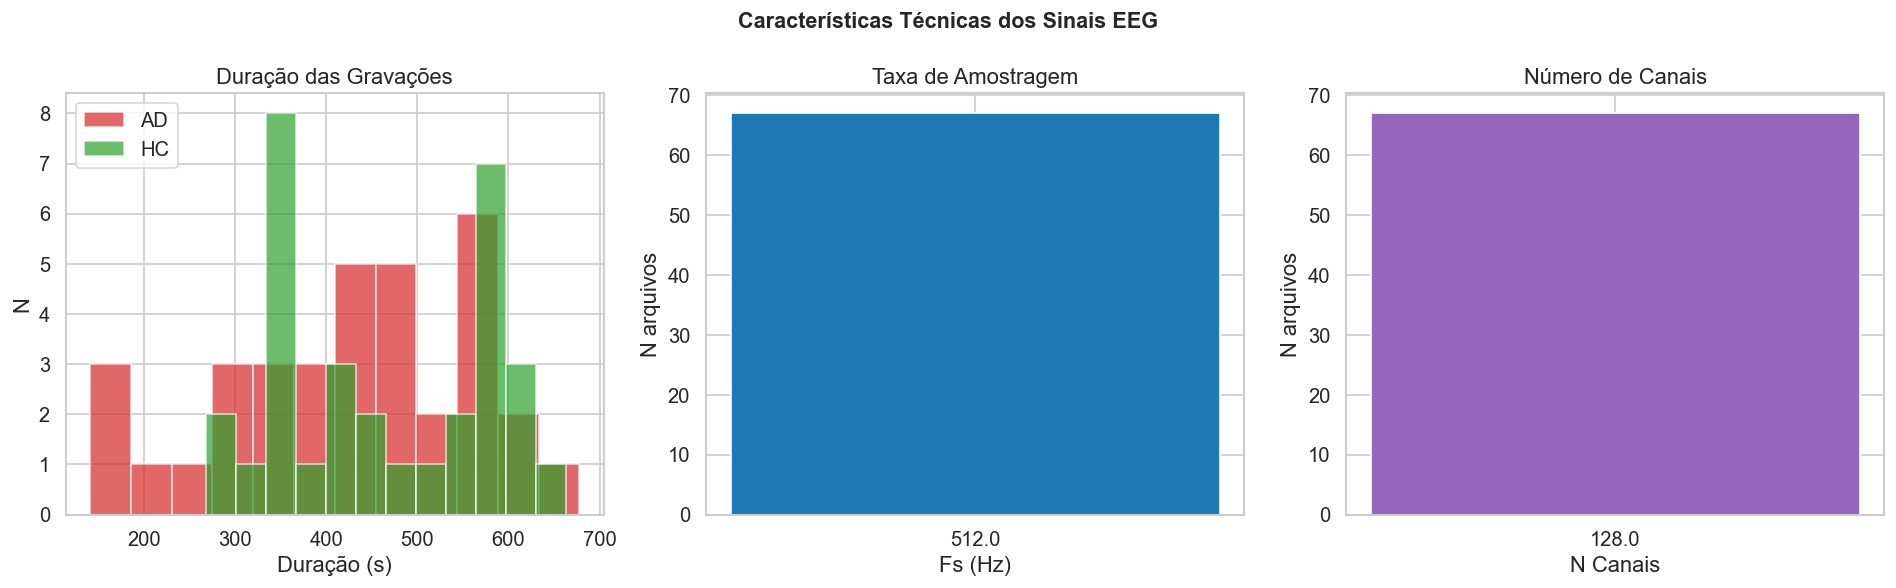

In [4]:
# 2.2 -- Metadados Técnicos dos Sinais EEG
print("Escaneando metadados dos arquivos EEG...\n")

tech_records = []
for group, folder in [("AD", DIR_AD), ("HC", DIR_HC)]:
    for fpath in Path(folder).rglob("*.set"):
        parts_upper = {p.upper() for p in fpath.parts}
        country = ("Argentina" if "AR" in parts_upper
                   else "Chile" if "CL" in parts_upper else "Other")
        try:
            raw = mne.io.read_raw_eeglab(str(fpath), preload=False, verbose=False)
            ch_types = Counter(raw.get_channel_types())
            tech_records.append({
                "Group"      : group,
                "Country"    : country,
                "File"       : fpath.name,
                "Duration_s" : round(raw.times[-1], 2),
                "Fs_Hz"      : raw.info["sfreq"],
                "N_Channels" : raw.info["nchan"],
                "N_EEG"      : ch_types.get("eeg", 0),
                "N_Bad"      : len(raw.info["bads"]),
            })
        except Exception:
            tech_records.append({
                "Group": group, "Country": country, "File": fpath.name,
                "Duration_s": None, "Fs_Hz": None,
                "N_Channels": None, "N_EEG": None, "N_Bad": None,
            })

df_tech = pd.DataFrame(tech_records)
print(f"{len(df_tech)} arquivos escaneados.")
display(df_tech.head(8))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Características Técnicas dos Sinais EEG", fontsize=13, fontweight="bold")

for grp, col in [("AD", "#d62728"), ("HC", "#2ca02c")]:
    sub = df_tech.loc[df_tech["Group"] == grp, "Duration_s"].dropna()
    axes[0].hist(sub, bins=12, alpha=0.7, color=col, label=grp)
axes[0].set_title("Duração das Gravações")
axes[0].set_xlabel("Duração (s)")
axes[0].set_ylabel("N")
axes[0].legend()

fs_counts = df_tech["Fs_Hz"].value_counts()
axes[1].bar(fs_counts.index.astype(str), fs_counts.values, color="#1f77b4")
axes[1].set_title("Taxa de Amostragem")
axes[1].set_xlabel("Fs (Hz)")
axes[1].set_ylabel("N arquivos")

ch_counts = df_tech["N_Channels"].value_counts().sort_index()
axes[2].bar(ch_counts.index.astype(str), ch_counts.values, color="#9467bd")
axes[2].set_title("Número de Canais")
axes[2].set_xlabel("N Canais")
axes[2].set_ylabel("N arquivos")

plt.tight_layout()
plt.show()


Visualizando: s6_sub-30035_rs-hep_eeg.set


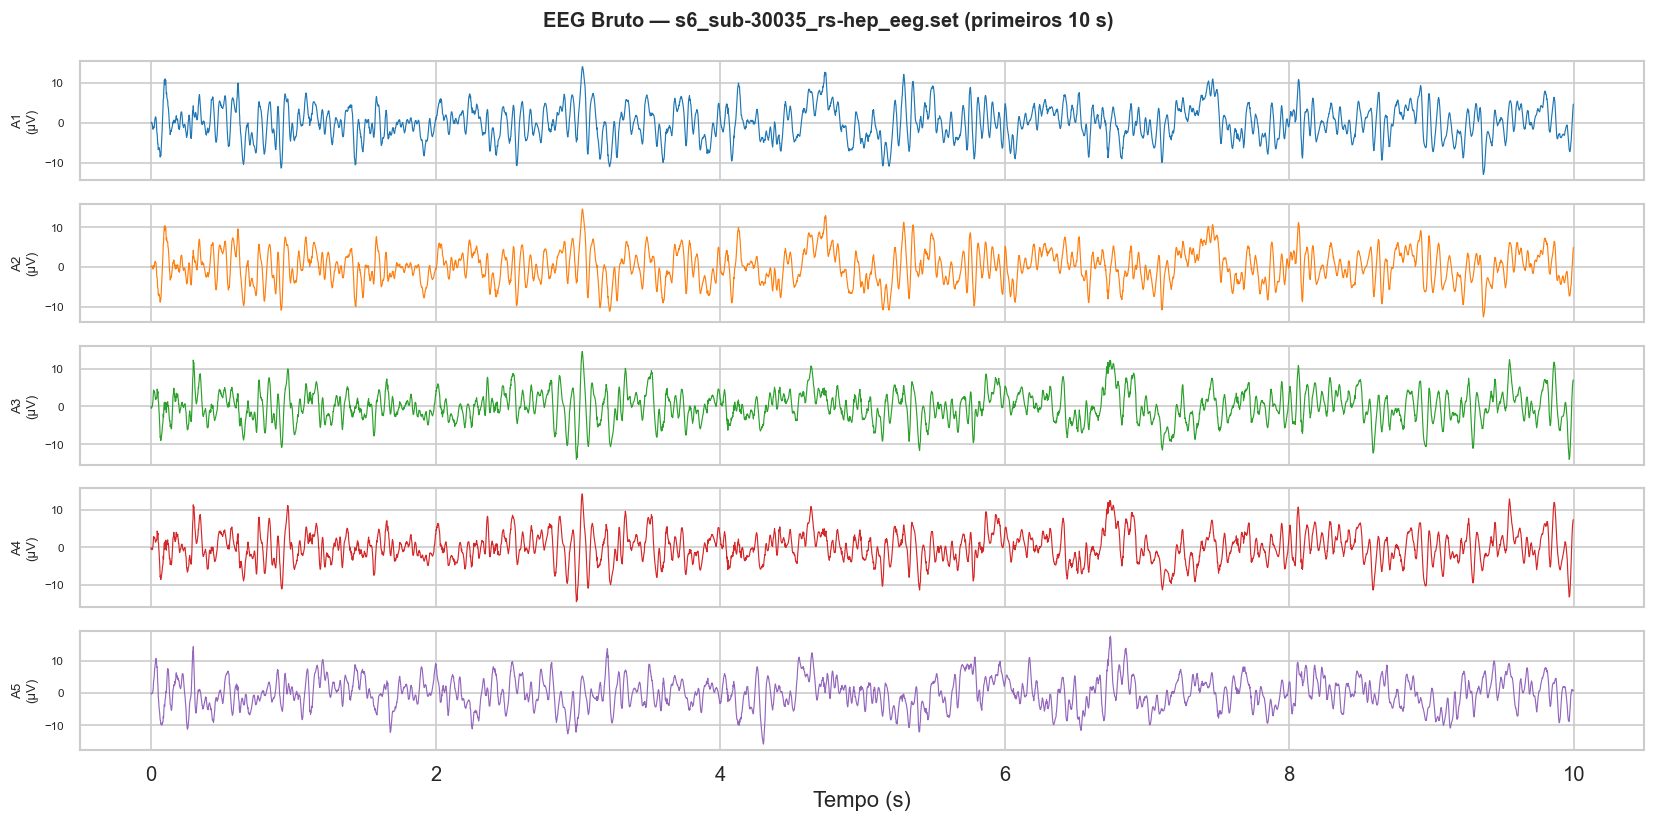

In [5]:
# 2.3 -- Inspeção Visual do EEG Bruto
# Abre o primeiro arquivo .set encontrado e plota os primeiros 10 s de 5 canais representativos.

first_set = next(Path(DIR_AD).rglob("*.set"), None) or next(Path(DIR_HC).rglob("*.set"), None)

if first_set:
    print(f"Visualizando: {first_set.name}")
    raw_viz  = mne.io.read_raw_eeglab(str(first_set), preload=True, verbose=False)
    sfreq    = raw_viz.info["sfreq"]
    channels = [c for c in raw_viz.ch_names
                if raw_viz.get_channel_types([c])[0] == "eeg"][:5]
    t_max    = min(10.0, raw_viz.times[-1])
    n_pts    = int(t_max * sfreq)
    times    = raw_viz.times[:n_pts]
    data     = raw_viz.get_data(picks=channels)[:, :n_pts]

    fig, axes = plt.subplots(len(channels), 1, figsize=(14, 7), sharex=True)
    fig.suptitle(f"EEG Bruto — {first_set.name} (primeiros {t_max:.0f} s)",
                 fontsize=12, fontweight="bold")
    for i, (ch, ax) in enumerate(zip(channels, axes)):
        ax.plot(times, data[i] * 1e6, lw=0.7, color=plt.cm.tab10(i))
        ax.set_ylabel(f"{ch}\n(µV)", fontsize=8)
        ax.yaxis.set_tick_params(labelsize=7)
    axes[-1].set_xlabel("Tempo (s)")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum arquivo .set encontrado. Execute a Fase 1 primeiro.")


---
### Fase 3 — Pré-processamento e Extração de Features

#### Pipeline de Processamento

```
.set (EEGLAB)
   → Carregamento robusto (.set + .fdt opcional)
   → Re-referência (média global)
   → Filtro passa-banda (0.5 – 45 Hz, FIR firwin)
   → Seleção de canais EEG
   → Épocas de duração fixa (4 s)
   → Normalização de amplitude por sujeito (RMS global = 1)
   → Welch PSD (por época, n_fft = min(512, comprimento_época))
   → Features espectrais: potência relativa por banda + razões + entropia espectral
   → Features de conectividade funcional: PLV por banda + correlação broadband
   → Saída: CSV com todas as épocas de todos os sujeitos
```

#### Features Extraídas

| Feature | Tipo | Descrição | Relevância Clínica |
|---------|------|-----------|-------------------|
| `Rel_Theta_mean` | Espectral | Potência relativa Theta (4–8 Hz) | Elevada em AD: lentificação cortical |
| `Rel_Alpha_mean` | Espectral | Potência relativa Alpha (8–13 Hz) | Reduzida em AD: disfunção tálamo-cortical |
| `Rel_Beta_mean` | Espectral | Potência relativa Beta (13–30 Hz) | Variável em AD |
| `Rel_Gamma_mean` | Espectral | Potência relativa Gamma (30–45 Hz) | Reduzida em AD: déficit de sincronização |
| `Razao_Theta_Alpha` | Espectral | Razão Theta/Alpha | Marcador clássico de declínio cognitivo |
| `Razao_Theta_Beta` | Espectral | Razão Theta/Beta | Relacionada à lentificação generalizada |
| `Spectral_Entropy` | Espectral | Entropia espectral | Reduzida em AD: regularidade EEG patológica |
| `PLV_Theta_mean` | **Conectividade** | PLV médio — banda Theta | Dessincronização theta em AD |
| `PLV_Alpha_mean` | **Conectividade** | PLV médio — banda Alpha | Redução de acoplamento alpha em AD |
| `PLV_Beta_mean` | **Conectividade** | PLV médio — banda Beta | Alterações de conectividade beta em AD |
| `Corr_Broadband_mean` | **Conectividade** | Correlação de Pearson média (\|r\|) broadband | Desconexão funcional global em AD |

> **PLV (Phase Locking Value):** mede a consistência do acoplamento de fase entre dois canais.
> Varia de 0 (ausência de sincronia) a 1 (sincronização perfeita).
> Computado via transformada de Hilbert após filtragem passa-banda por sujeito.


In [6]:
# 3.1 -- Funções Auxiliares: ID de Sujeito e Carregamento de Arquivo

def extract_subject_id(fpath: Path) -> str:
    """Extrai o ID do sujeito (ex.: sub-30007) a partir do nome do arquivo."""
    m = re.search(r"(sub-\d+)", fpath.stem, flags=re.IGNORECASE)
    if m:
        return m.group(1)
    m = re.search(r"sub[-_]?(\d+)", fpath.stem, flags=re.IGNORECASE)
    if m:
        return f"sub-{m.group(1)}"
    return fpath.stem


def infer_country(fpath: Path) -> str:
    """Infere o país de gravação a partir do caminho (AR=Argentina, CL=Chile)."""
    parts = {p.upper() for p in fpath.parts}
    if "AR" in parts:
        return "Argentina"
    if "CL" in parts:
        return "Chile"
    return "Other"


def load_raw_safe(fpath: Path):
    """
    Carrega um arquivo .set de forma robusta.
    Se o arquivo .fdt pareado estiver ausente do diretório de trabalho,
    tenta uma cópia em diretório temporário como fallback.
    """
    try:
        return mne.io.read_raw_eeglab(str(fpath), preload=True, verbose=False)
    except Exception as exc:
        msg = str(exc).lower()
        if "fdt" in msg or "not found" in msg:
            fdt = fpath.with_suffix(".fdt")
            if fdt.exists():
                from tempfile import TemporaryDirectory
                with TemporaryDirectory() as tmp:
                    tmp_p = Path(tmp)
                    (tmp_p / fpath.name).write_bytes(fpath.read_bytes())
                    (tmp_p / fdt.name).write_bytes(fdt.read_bytes())
                    return mne.io.read_raw_eeglab(
                        str(tmp_p / fpath.name), preload=True, verbose=False)
        raise exc

print("Funções auxiliares definidas.")


Funções auxiliares definidas.


In [7]:
# 3.2 -- Função de Extração de Features Espectrais (Welch PSD)

def extract_spectral_features(data: np.ndarray, sfreq: float) -> dict:
    """
    Computa features espectrais para UMA época EEG.

    Parâmetros
    ----------
    data  : array 2D (n_canais x n_amostras), normalizado em amplitude (RMS global ~ 1)
    sfreq : frequência de amostragem (Hz)

    Retorna
    -------
    dict com potências relativas por banda, razões espectrais e entropia espectral.
    """
    data = np.asarray(data, dtype=float)
    if data.ndim != 2:
        raise ValueError(f"Array 2D esperado, obtido shape={data.shape}")

    n_fft = min(512, data.shape[-1])
    psds, freqs = psd_array_welch(
        data, sfreq=sfreq, fmin=FMIN, fmax=FMAX,
        n_fft=n_fft, verbose=False
    )
    psd_mean = np.mean(psds, axis=0)

    integrate = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

    band_power = {}
    for band, (flo, fhi) in BANDS.items():
        idx = (freqs >= flo) & (freqs < fhi)
        band_power[band] = (float(integrate(psd_mean[idx], freqs[idx]))
                            if np.sum(idx) >= 2 else 0.0)

    total = sum(band_power.values()) + 1e-12

    features = {
        "Rel_Delta_mean" : band_power["Delta"] / total,
        "Rel_Theta_mean" : band_power["Theta"] / total,
        "Rel_Alpha_mean" : band_power["Alpha"] / total,
        "Rel_Beta_mean"  : band_power["Beta"]  / total,
        "Rel_Gamma_mean" : band_power["Gamma"] / total,
    }
    features["Razao_Theta_Alpha"] = (features["Rel_Theta_mean"]
                                     / (features["Rel_Alpha_mean"] + 1e-12))
    features["Razao_Theta_Beta"]  = (features["Rel_Theta_mean"]
                                     / (features["Rel_Beta_mean"]  + 1e-12))

    psd_norm = psd_mean / (np.sum(psd_mean) + 1e-12)
    features["Spectral_Entropy"] = float(-np.sum(psd_norm * np.log2(psd_norm + 1e-12)))

    return features

print("Função de features espectrais definida.")


Função de features espectrais definida.


In [8]:
# 3.3 -- Função de Extração de Conectividade Funcional (PLV + Correlação)
#
# Phase Locking Value (PLV):
#   Mede a consistência do acoplamento de fase entre pares de canais.
#   PLV = | mean( exp(i * Δφ) ) |,  onde Δφ = φ_i − φ_j
#   Implementação vetorizada via transformada de Hilbert.
#
# Correlação de Pearson (broadband):
#   |r| médio de todos os pares de canais — índice de acoplamento de amplitude.
#
# CORREÇÕES:
#   • butter(output='ba') → butter(output='sos') + sosfiltfilt
#     (filtros ba de ordem 4 são numericamente instáveis para Fs alta)
#   • Guard: mínimo de amostras para filtfilt (padlen = 3 × ordem_sos × 2)

def extract_connectivity_features(data: np.ndarray, sfreq: float) -> dict:
    """
    Computa features de conectividade funcional para UMA época EEG.

    Parâmetros
    ----------
    data  : array 2D (n_canais x n_amostras)
    sfreq : frequência de amostragem (Hz)

    Retorna
    -------
    dict com PLV médio por banda (Theta, Alpha, Beta) e correlação broadband média.
    """
    data = np.asarray(data, dtype=float)
    if data.ndim != 2:
        raise ValueError(f"Array 2D esperado, obtido shape={data.shape}")

    n_ch, n_samp = data.shape
    nan_feat = {
        "PLV_Theta_mean"     : np.nan,
        "PLV_Alpha_mean"     : np.nan,
        "PLV_Beta_mean"      : np.nan,
        "Corr_Broadband_mean": np.nan,
    }

    if n_ch < 2:
        return nan_feat

    # ── 1. Correlação de Pearson broadband (vetorizado) ──────────────────
    corr_mat = np.corrcoef(data)                          # n_ch × n_ch
    iu = np.triu_indices(n_ch, k=1)                       # índices do triângulo superior
    corr_vals = np.abs(corr_mat[iu])
    corr_broadband = float(np.nanmean(corr_vals))

    # ── 2. PLV por banda (vetorizado via Hilbert) ─────────────────────────
    nyq = sfreq / 2.0
    FILTER_ORDER = 4
    # sosfiltfilt precisa de pelo menos 3 × n_sections amostras para padding
    # n_sections de um Butterworth passa-banda de ordem N = N seções sos
    MIN_SAMP_FOR_FILTER = 3 * FILTER_ORDER * 6  # margem conservadora
    plv_results = {}

    for band_name, (flo, fhi) in CONN_BANDS.items():
        fhi_safe = min(fhi, nyq * 0.99)
        if flo >= fhi_safe or n_samp < MIN_SAMP_FOR_FILTER:
            plv_results[f"PLV_{band_name}_mean"] = np.nan
            continue

        # ── Filtro Butterworth passa-banda — SOS para estabilidade numérica ──
        sos = butter(FILTER_ORDER, [flo / nyq, fhi_safe / nyq],
                     btype="band", output="sos")
        data_filt = sosfiltfilt(sos, data, axis=1)        # n_ch × n_samp

        # Fase instantânea via sinal analítico (Hilbert)
        analytic = hilbert(data_filt, axis=1)
        phases   = np.angle(analytic)                      # n_ch × n_samp

        # PLV entre todos os pares — implementação vetorizada:
        # Δφ[i,j,t] = φ[i,t] − φ[j,t]
        # PLV[i,j]  = |mean_t( exp(i·Δφ) )|
        phase_exp = np.exp(1j * phases)                    # n_ch × n_samp (complexo)
        plv_mat   = np.abs(
            (phase_exp @ phase_exp.conj().T) / n_samp
        )                                                  # n_ch × n_ch

        plv_vals = plv_mat[iu]                             # apenas triângulo superior
        plv_results[f"PLV_{band_name}_mean"] = float(np.nanmean(plv_vals))

    return {
        "PLV_Theta_mean"     : plv_results.get("PLV_Theta_mean",     np.nan),
        "PLV_Alpha_mean"     : plv_results.get("PLV_Alpha_mean",     np.nan),
        "PLV_Beta_mean"      : plv_results.get("PLV_Beta_mean",      np.nan),
        "Corr_Broadband_mean": corr_broadband,
    }

print("Função de conectividade funcional definida.")


Função de conectividade funcional definida.


In [9]:
# 3.4 -- Loop Principal de Pré-processamento e Extração
# CORREÇÕES:
#   • Removidos imports e LABEL_MAP duplicados (já definidos em 0.1 / 0.2)
#   • float32 → float64: evita perda de precisão no cálculo de PLV/Hilbert
#   • raw.pick_types() (deprecated MNE ≥ 1.0) → raw.pick('eeg')
#   • Verificação de NaN/inf nas features extraídas antes de anexar ao dataset

all_epochs = []
failed_files = []
subject_label_registry = {}  # garante consistência: mesmo sujeito → mesmo rótulo

for group, folder in [("AD", DIR_AD), ("HC", DIR_HC)]:
    files = sorted(Path(folder).rglob("*.set"))
    print(f"\n{'=' * 60}")
    print(f"  Grupo {group}: {len(files)} arquivo(s) encontrado(s)")
    print(f"{'=' * 60}")

    if group not in LABEL_MAP:
        raise ValueError(f"Grupo inválido: {group}. Esperado: {list(LABEL_MAP.keys())}")

    group_label = LABEL_MAP[group]

    for fpath in files:
        try:
            subject_id = extract_subject_id(fpath)
            country    = infer_country(fpath)

            raw = load_raw_safe(fpath)
            if raw is None:
                raise RuntimeError("load_raw_safe retornou None.")

            raw.set_eeg_reference("average", projection=False)
            raw.filter(FMIN, FMAX, fir_design="firwin", verbose=False)

            # pick('eeg') substitui pick_types() que foi depreciado no MNE >= 1.0
            raw.pick("eeg")

            epochs = mne.make_fixed_length_epochs(
                raw,
                duration=4.0,
                preload=True,
                verbose=False,
            )

            if len(epochs) == 0:
                raise RuntimeError("Nenhuma época gerada (arquivo muito curto ou inválido).")

            # float64 preserva precisão numérica para PLV e Hilbert
            data  = epochs.get_data().astype(np.float64)   # (n_epochs, n_channels, n_times)
            sfreq = float(raw.info["sfreq"])

            # Normalização global por sujeito via RMS
            global_rms = np.sqrt(np.mean(data ** 2))
            if not np.isfinite(global_rms) or global_rms < 1e-12:
                global_rms = 1.0
            data_norm = data / global_rms

            # Registra e valida consistência do rótulo por sujeito
            if subject_id in subject_label_registry:
                if subject_label_registry[subject_id] != group_label:
                    raise ValueError(
                        f"Inconsistência de rótulo para {subject_id}: "
                        f"{subject_label_registry[subject_id]} vs {group_label}"
                    )
            else:
                subject_label_registry[subject_id] = group_label

            n_ok   = 0
            n_fail = 0

            for epoch_idx, epoch in enumerate(data_norm):
                try:
                    feat = extract_spectral_features(epoch, sfreq)
                    conn = extract_connectivity_features(epoch, sfreq)
                    feat.update(conn)

                    # Guard: rejeitar época se alguma feature obrigatória for NaN/inf
                    bad_feats = [k for k in FEATURE_COLS
                                 if k in feat and not np.isfinite(feat.get(k, np.nan))]
                    if bad_feats:
                        raise ValueError(f"Features com NaN/inf detectadas: {bad_feats}")

                    feat.update({
                        "subject_id" : subject_id,
                        "label_text" : group,       # "AD" / "HC"
                        "label"      : group_label, # 1 / 0
                        "country"    : country,
                        "epoch_id"   : epoch_idx,
                        "source_file": fpath.name,
                    })

                    all_epochs.append(feat)
                    n_ok += 1

                except Exception as e_epoch:
                    n_fail += 1
                    failed_files.append({
                        "group"    : group,
                        "file"     : fpath.name,
                        "path"     : str(fpath),
                        "error"    : f"Erro na extração da época {epoch_idx}: {e_epoch}",
                        "traceback": traceback.format_exc(),
                    })

            print(
                f"  OK   {subject_id:<18} | épocas={len(data):3d} "
                f"| extraídas={n_ok:3d} | falhas={n_fail:3d} "
                f"| Fs={sfreq:.0f} Hz | canais={data.shape[1]} | país={country}"
            )

        except Exception as exc:
            failed_files.append({
                "group"    : group,
                "file"     : fpath.name,
                "path"     : str(fpath),
                "error"    : str(exc),
                "traceback": traceback.format_exc(),
            })
            print(f"  FALHA {fpath.name}  =>  {exc}")



  Grupo AD: 35 arquivo(s) encontrado(s)
  OK   sub-30001          | épocas= 78 | extraídas= 78 | falhas=  0 | Fs=512 Hz | canais=128 | país=Argentina
  OK   sub-30002          | épocas= 80 | extraídas= 80 | falhas=  0 | Fs=512 Hz | canais=128 | país=Argentina
  OK   sub-30004          | épocas= 71 | extraídas= 71 | falhas=  0 | Fs=512 Hz | canais=128 | país=Argentina
  OK   sub-30008          | épocas= 78 | extraídas= 78 | falhas=  0 | Fs=512 Hz | canais=128 | país=Argentina
  OK   sub-30009          | épocas=101 | extraídas=101 | falhas=  0 | Fs=512 Hz | canais=128 | país=Argentina
  OK   sub-30011          | épocas= 35 | extraídas= 35 | falhas=  0 | Fs=512 Hz | canais=128 | país=Argentina
  OK   sub-30012          | épocas= 56 | extraídas= 56 | falhas=  0 | Fs=512 Hz | canais=128 | país=Argentina
  OK   sub-30013          | épocas= 92 | extraídas= 92 | falhas=  0 | Fs=512 Hz | canais=128 | país=Argentina
  OK   sub-30015          | épocas= 40 | extraídas= 40 | falhas=  0 | Fs=512 Hz

#### Nota: Por que alguns arquivos `.set` falham ao carregar

Arquivos `.set` do EEGLAB armazenam apenas metadados. Os dados binários do EEG bruto ficam em um
arquivo `.fdt` pareado com o mesmo nome base.

**Erro:** `File ...sub-XXXXX_rs_eeg.fdt not found`

Ocorre quando o arquivo `.fdt` está ausente do mesmo diretório.

**Impacto:** Sujeitos sem o arquivo `.fdt` não podem ser processados.
Todos os sujeitos AD do BrainLat são auto-contidos (dados embutidos no `.set`);
um subconjunto de sujeitos HC usa o formato dividido `.set`/`.fdt`.

**Ação:** Verifique se os arquivos `.fdt` ausentes podem ser recuperados do download original.
O pipeline continua com os dados disponíveis.


In [10]:
# 3.5 -- Salvar Features e Exibir Resumo da Extração
# CORREÇÕES:
#   • "label_text" adicionado a cols_meta (antes vazava para cols_feat)
#   • df_full["label"] comparado com string "AD"/"HC" → corrigido para
#     df_full["label_text"] (label é int 0/1; a comparação anterior sempre
#     retornava False, zerando todos os contadores)

df_full   = pd.DataFrame(all_epochs)
df_failed = pd.DataFrame(failed_files)

if df_full.empty:
    raise RuntimeError("Nenhuma época extraída. Verifique os caminhos e a Fase 1.")

# label_text incluído em cols_meta para não poluir cols_feat
cols_meta = ["subject_id", "label_text", "label", "country", "epoch_id", "source_file"]
cols_feat = [c for c in df_full.columns if c not in cols_meta]
df_full   = df_full[cols_meta + cols_feat]

df_full.to_csv(OUT_CSV_FULL,    index=False, encoding="utf-8-sig")
df_failed.to_csv(OUT_CSV_FAILED, index=False, encoding="utf-8-sig")

# Usar label_text (str "AD"/"HC") — label é int 0/1
n_subj_ad = df_full.loc[df_full["label_text"] == "AD", "subject_id"].nunique()
n_subj_hc = df_full.loc[df_full["label_text"] == "HC", "subject_id"].nunique()
n_ep_ad   = (df_full["label_text"] == "AD").sum()
n_ep_hc   = (df_full["label_text"] == "HC").sum()

print(f"{'=' * 60}")
print("  RESUMO DA EXTRAÇÃO")
print(f"{'=' * 60}")
print(f"  Sujeitos AD    : {n_subj_ad}")
print(f"  Sujeitos HC    : {n_subj_hc}")
print(f"  Épocas AD      : {n_ep_ad:,}")
print(f"  Épocas HC      : {n_ep_hc:,}")
print(f"  Total épocas   : {len(df_full):,}")
print(f"  Falhas         : {len(df_failed)}")
print(f"  Features       : {cols_feat}")
print(f"{'=' * 60}")
print(f"\n  Salvo em: {OUT_CSV_FULL}")


  RESUMO DA EXTRAÇÃO
  Sujeitos AD    : 35
  Sujeitos HC    : 32
  Épocas AD      : 3,716
  Épocas HC      : 3,709
  Total épocas   : 7,425
  Falhas         : 14
  Features       : ['Rel_Delta_mean', 'Rel_Theta_mean', 'Rel_Alpha_mean', 'Rel_Beta_mean', 'Rel_Gamma_mean', 'Razao_Theta_Alpha', 'Razao_Theta_Beta', 'Spectral_Entropy', 'PLV_Theta_mean', 'PLV_Alpha_mean', 'PLV_Beta_mean', 'Corr_Broadband_mean']

  Salvo em: eeg_features_brainlat_FULL.csv


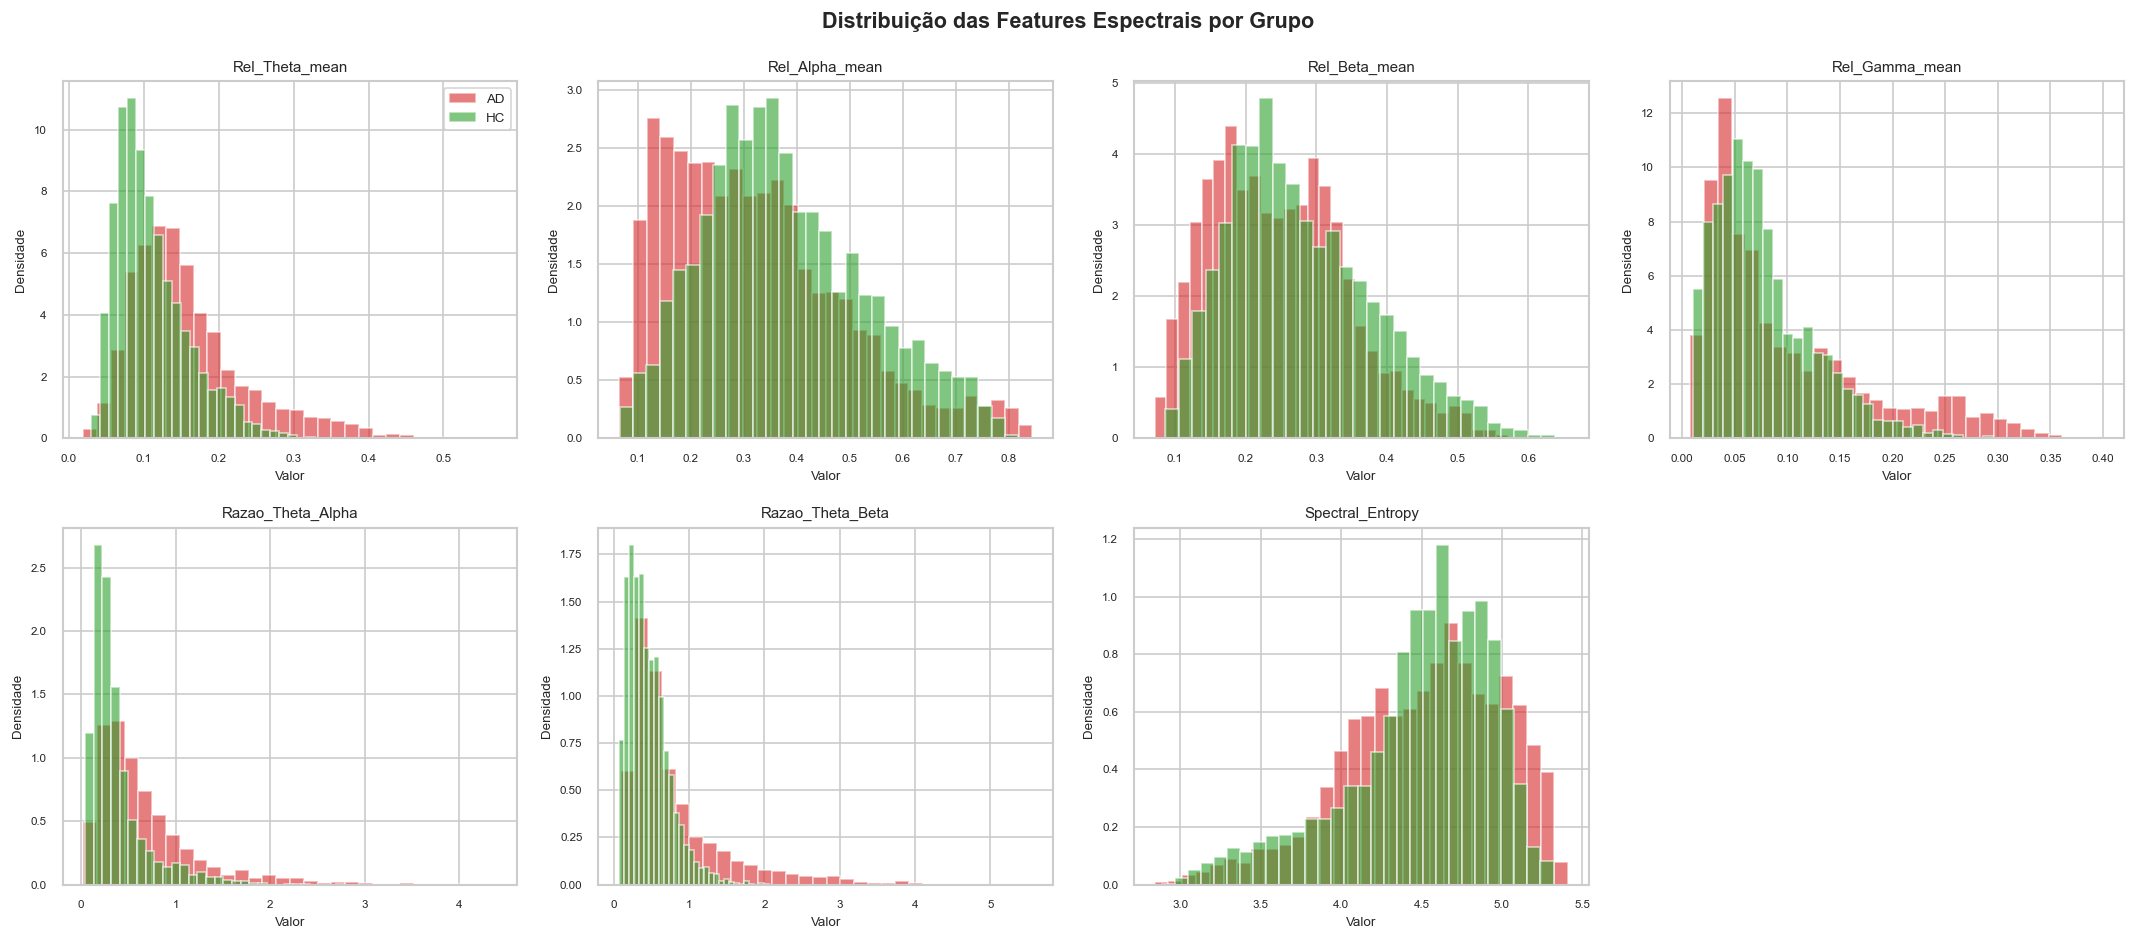

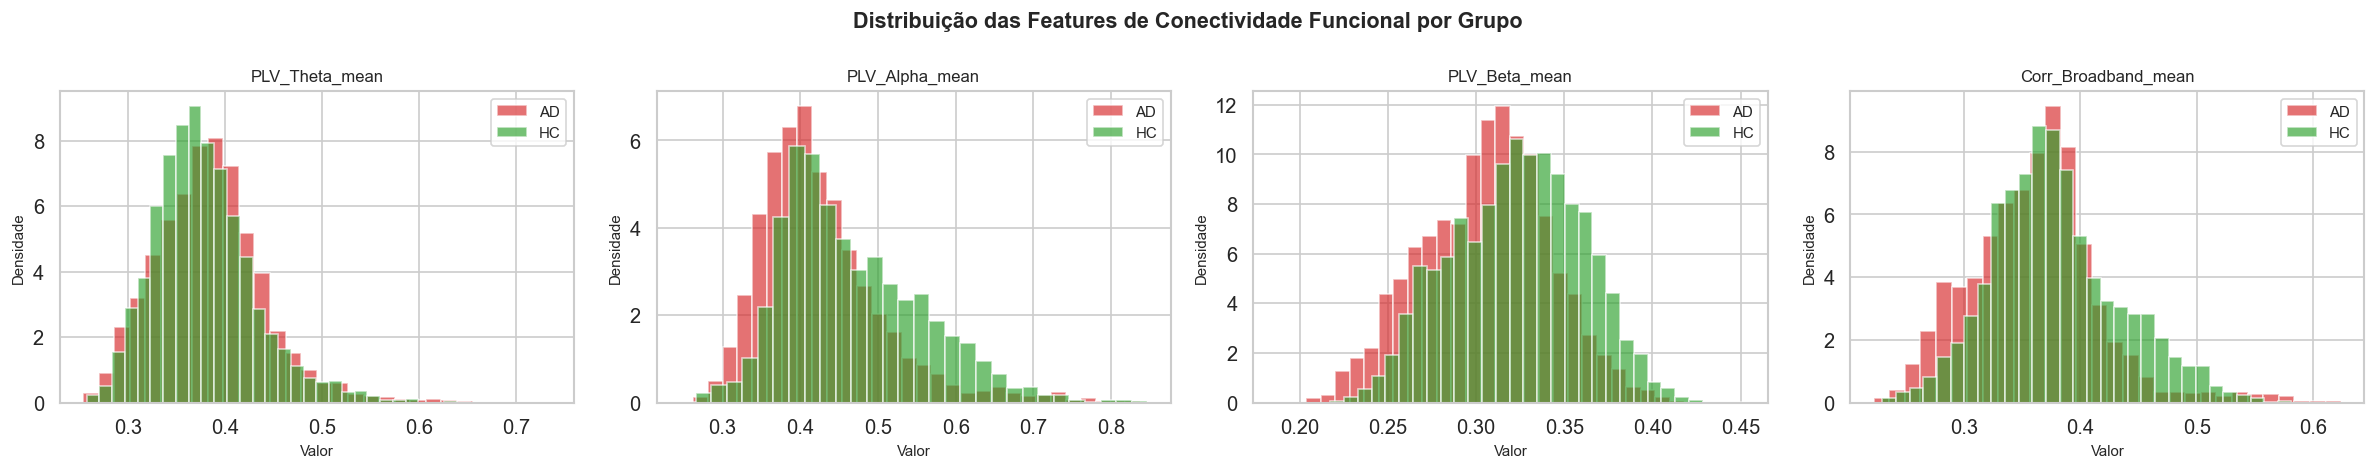

In [11]:
# 3.6 -- Visualização: Distribuições das Features por Grupo

# ── Features espectrais ──────────────────────────────────────────────────
spectral_feats = [c for c in cols_feat if not any(
    k in c for k in ["PLV", "Corr", "Delta", "subject", "epoch", "source"])]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Distribuição das Features Espectrais por Grupo", fontsize=13, fontweight="bold")
for i, feat in enumerate(spectral_feats[:8]):
    ax = axes[i // 4][i % 4]
    for grp, col in [("AD", "#d62728"), ("HC", "#2ca02c")]:
        sub = df_full.loc[df_full["label_text"] == grp, feat].dropna()
        ax.hist(sub, bins=30, alpha=0.6, color=col, label=grp, density=True)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("Valor", fontsize=8)
    ax.set_ylabel("Densidade", fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=8)
for j in range(len(spectral_feats[:8]), 8):
    axes[j // 4][j % 4].set_visible(False)
plt.tight_layout()
plt.show()

# ── Features de conectividade funcional ─────────────────────────────────
conn_feats = [c for c in cols_feat if any(k in c for k in ["PLV", "Corr"])]
if conn_feats:
    fig, axes = plt.subplots(1, len(conn_feats), figsize=(5 * len(conn_feats), 4))
    if len(conn_feats) == 1:
        axes = [axes]
    fig.suptitle("Distribuição das Features de Conectividade Funcional por Grupo",
                 fontsize=13, fontweight="bold")
    for ax, feat in zip(axes, conn_feats):
        for grp, col in [("AD", "#d62728"), ("HC", "#2ca02c")]:
            sub = df_full.loc[df_full["label_text"] == grp, feat].dropna()
            ax.hist(sub, bins=30, alpha=0.65, color=col, label=grp, density=True)
        ax.set_title(feat, fontsize=10)
        ax.set_xlabel("Valor", fontsize=9)
        ax.set_ylabel("Densidade", fontsize=9)
        ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


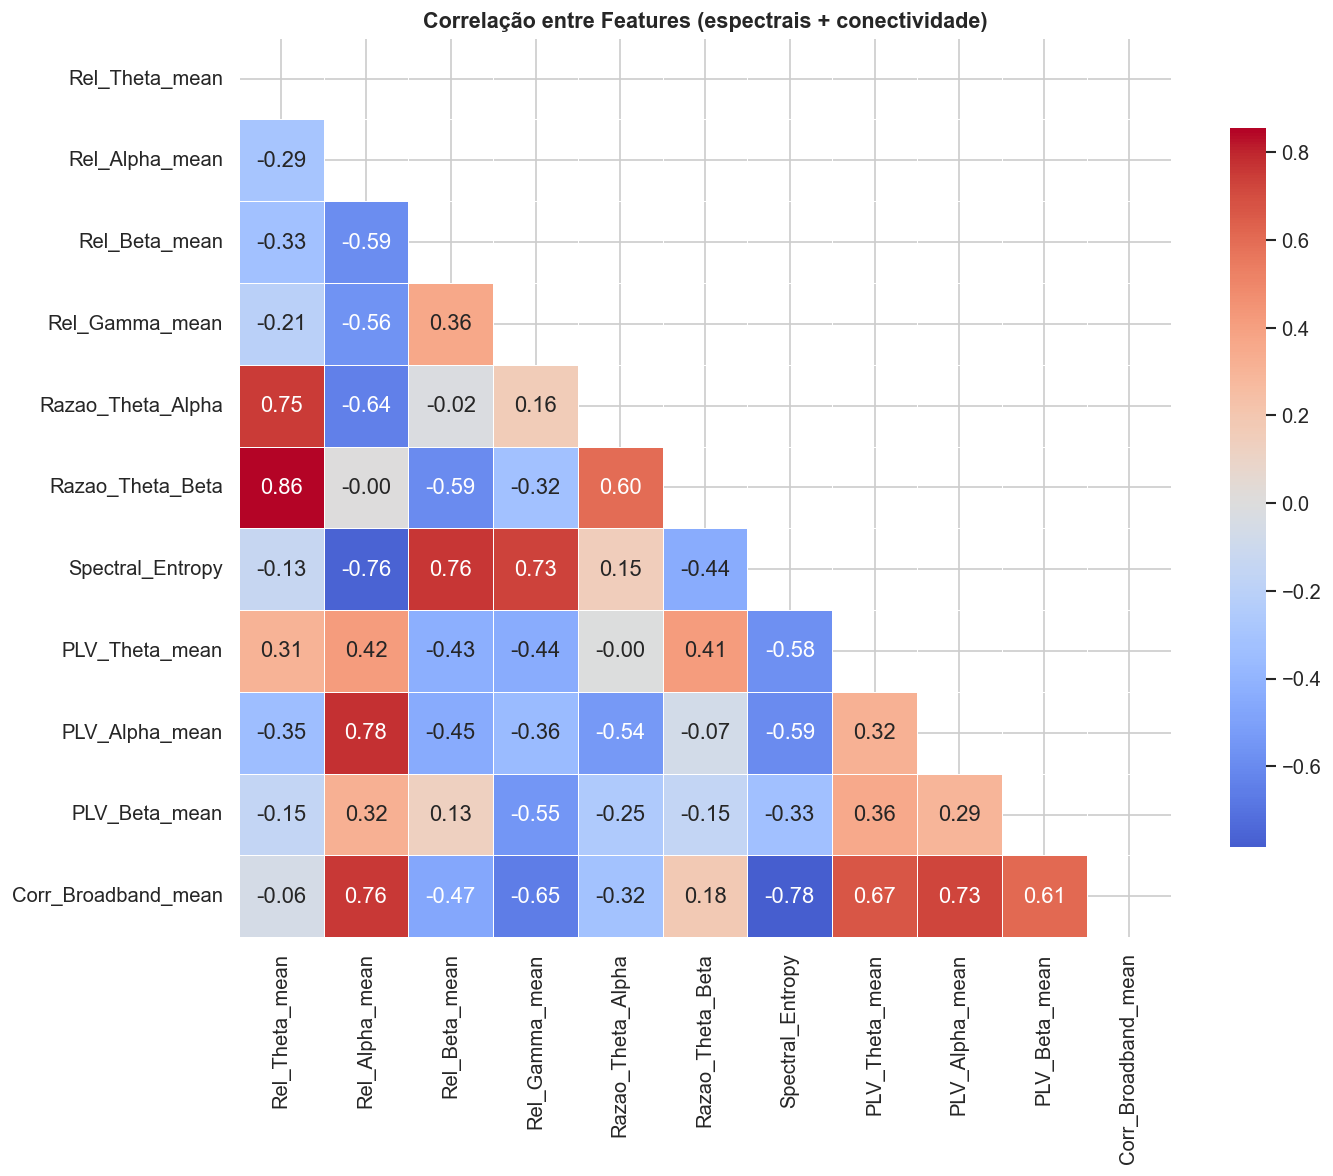

In [12]:
# 3.7 -- Mapa de Correlação entre Features (Heatmap)

feat_data = df_full[FEATURE_COLS].dropna()
corr_feat = feat_data.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_feat, dtype=bool))
sns.heatmap(
    corr_feat, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title("Correlação entre Features (espectrais + conectividade)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [13]:
# 3.8 -- Teste Mann-Whitney U: Significância das Features por Grupo
#
# Para cada feature, testa se a distribuição difere significativamente
# entre AD e HC (teste não-paramétrico, bicaudal).

from scipy.stats import mannwhitneyu

print(f"{'Feature':<25} {'U-stat':>10} {'p-value':>12} {'Significativo':>15}")
print("-" * 65)

for feat in FEATURE_COLS:
    vals_ad = df_full.loc[df_full["label_text"] == "AD", feat].dropna().values
    vals_hc = df_full.loc[df_full["label_text"] == "HC", feat].dropna().values
    if len(vals_ad) < 2 or len(vals_hc) < 2:
        continue
    u_stat, p_val = mannwhitneyu(vals_ad, vals_hc, alternative="two-sided")
    sig = "✓ p<0.05" if p_val < 0.05 else "✗"
    print(f"{feat:<25} {u_stat:>10.1f} {p_val:>12.4e} {sig:>15}")


Feature                       U-stat      p-value   Significativo
-----------------------------------------------------------------
Rel_Theta_mean             9724859.0  1.0068e-206        ✓ p<0.05
Rel_Alpha_mean             5346602.0   8.4500e-63        ✓ p<0.05
Rel_Beta_mean              5721300.0   8.7880e-37        ✓ p<0.05
Rel_Gamma_mean             7423802.0   8.1334e-09        ✓ p<0.05
Razao_Theta_Alpha          9845852.0  1.4295e-224        ✓ p<0.05
Razao_Theta_Beta           9307485.0  7.1735e-151        ✓ p<0.05
Spectral_Entropy           7106619.0   1.9742e-02        ✓ p<0.05
PLV_Theta_mean             7424971.0   7.5447e-09        ✓ p<0.05
PLV_Alpha_mean             4947051.0   2.1695e-98        ✓ p<0.05
PLV_Beta_mean              5084758.0   3.2984e-85        ✓ p<0.05
Corr_Broadband_mean        5667826.0   4.6359e-40        ✓ p<0.05
